# 🎌 Clasificación de Sentimientos en Reseñas de Anime — MyAnimeList

**Proyecto:** Mini-Proyecto NLP — Pipeline Completo  
**Curso:** INFB6093 — Procesamiento de Lenguaje Natural · 2026-I  
**Institución:** Universidad Tecnológica Metropolitana (UTEM)  
**Integrantes:** Diego Silva Madariaga · Bastián Cortez Arce  
**Profesor:** Jaime Andrés Jiménez

---

| Paso | Contenido |
|------|-----------|
| **1** | Setup: clonar repo e instalar dependencias |
| **2** | Definición de la tarea |
| **3** | Recolección de datos (descarga desde HuggingFace) |
| **4** | Limpieza — `limpieza.py` |
| **5** | Balanceo de clases — `balanceo.py` |
| **6** | Análisis exploratorio (EDA) |
| **7** | Continued Pretraining MLM — `pretrain_mlm.py` |
| **8** | Entrenamiento DistilBERT + BiLSTM — `entrenar_distilbert_bilstm.py` |
| **9** | Análisis de errores — `error_analysis.py` |
| **10** | Resultados finales |

> ⚠️ **GPU requerida:** Runtime → Change runtime type → T4 GPU  
> ▶️ Ejecutar todas las celdas en orden: Runtime → Run all


In [ ]:
!git clone https://github.com/DESM2025/NLP-mal-review-classifier.git
%cd NLP-mal-review-classifier

!pip install -q -r requirements.txt
!pip install -q datasets

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n✅ Dispositivo: {device}')
if device.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  Sin GPU — habilita T4 en Runtime → Change runtime type')

import os
print(f'\nDirectorio: {os.getcwd()}')
print('Scripts disponibles:', sorted(os.listdir('scripts')))


Cloning into 'NLP-mal-review-classifier'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 72 (delta 31), reused 58 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 2.40 MiB | 34.56 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/NLP-mal-review-classifier
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.9 MB/s eta 0:00:00

✅ Dispositivo: cuda
   GPU : Tesla T4
   VRAM: 15.6 GB

Directorio: /content/NLP-mal-review-classifier
Scripts disponibles: ['balanceo.py', 'entrenar_distilbert_bilstm.py', 'error_analysis.py', 'limpieza.py', 'pretrain_mlm.py', 'scraper_mal.py', 'scraper_negativos.py', 'sweep_bilstm.py']


---
## Paso 2 — Definición de la Tarea

**Tarea NLP:** Clasificación binaria de sentimientos en reseñas de anime de MyAnimeList (MAL).

Dado un texto $x$ (reseña en inglés), el modelo predice $\hat{y} \in \{0=\text{Negativa},\; 1=\text{Positiva}\}$.

### Desafíos del dominio

| Desafío | Ejemplo real | Por qué es difícil |
|---------|-------------|-------------------|
| **Ironía / sarcasmo** | *"What a masterpiece... if you enjoy watching paint dry"* | Palabras positivas, sentimiento negativo |
| **Reseñas mixtas** | 3 párrafos negativos + conclusión positiva | El veredicto final revierte el cuerpo |
| **Jerga del dominio** | *"plot armor"*, *"waifu bait"*, *"nakama power"* | Ausente en corpus generales como Wikipedia |
| **Textos largos** | Media ~650 tokens por reseña | Supera el límite de 512 tokens de BERT estándar |
| **Sesgo positivo** | ~70% positivas en datos crudos | Un modelo trivial lograría alta accuracy sin aprender nada |

### Pipeline del proyecto
```
Descarga HF → limpieza.py → balanceo.py → pretrain_mlm.py → entrenar_distilbert_bilstm.py → error_analysis.py
```


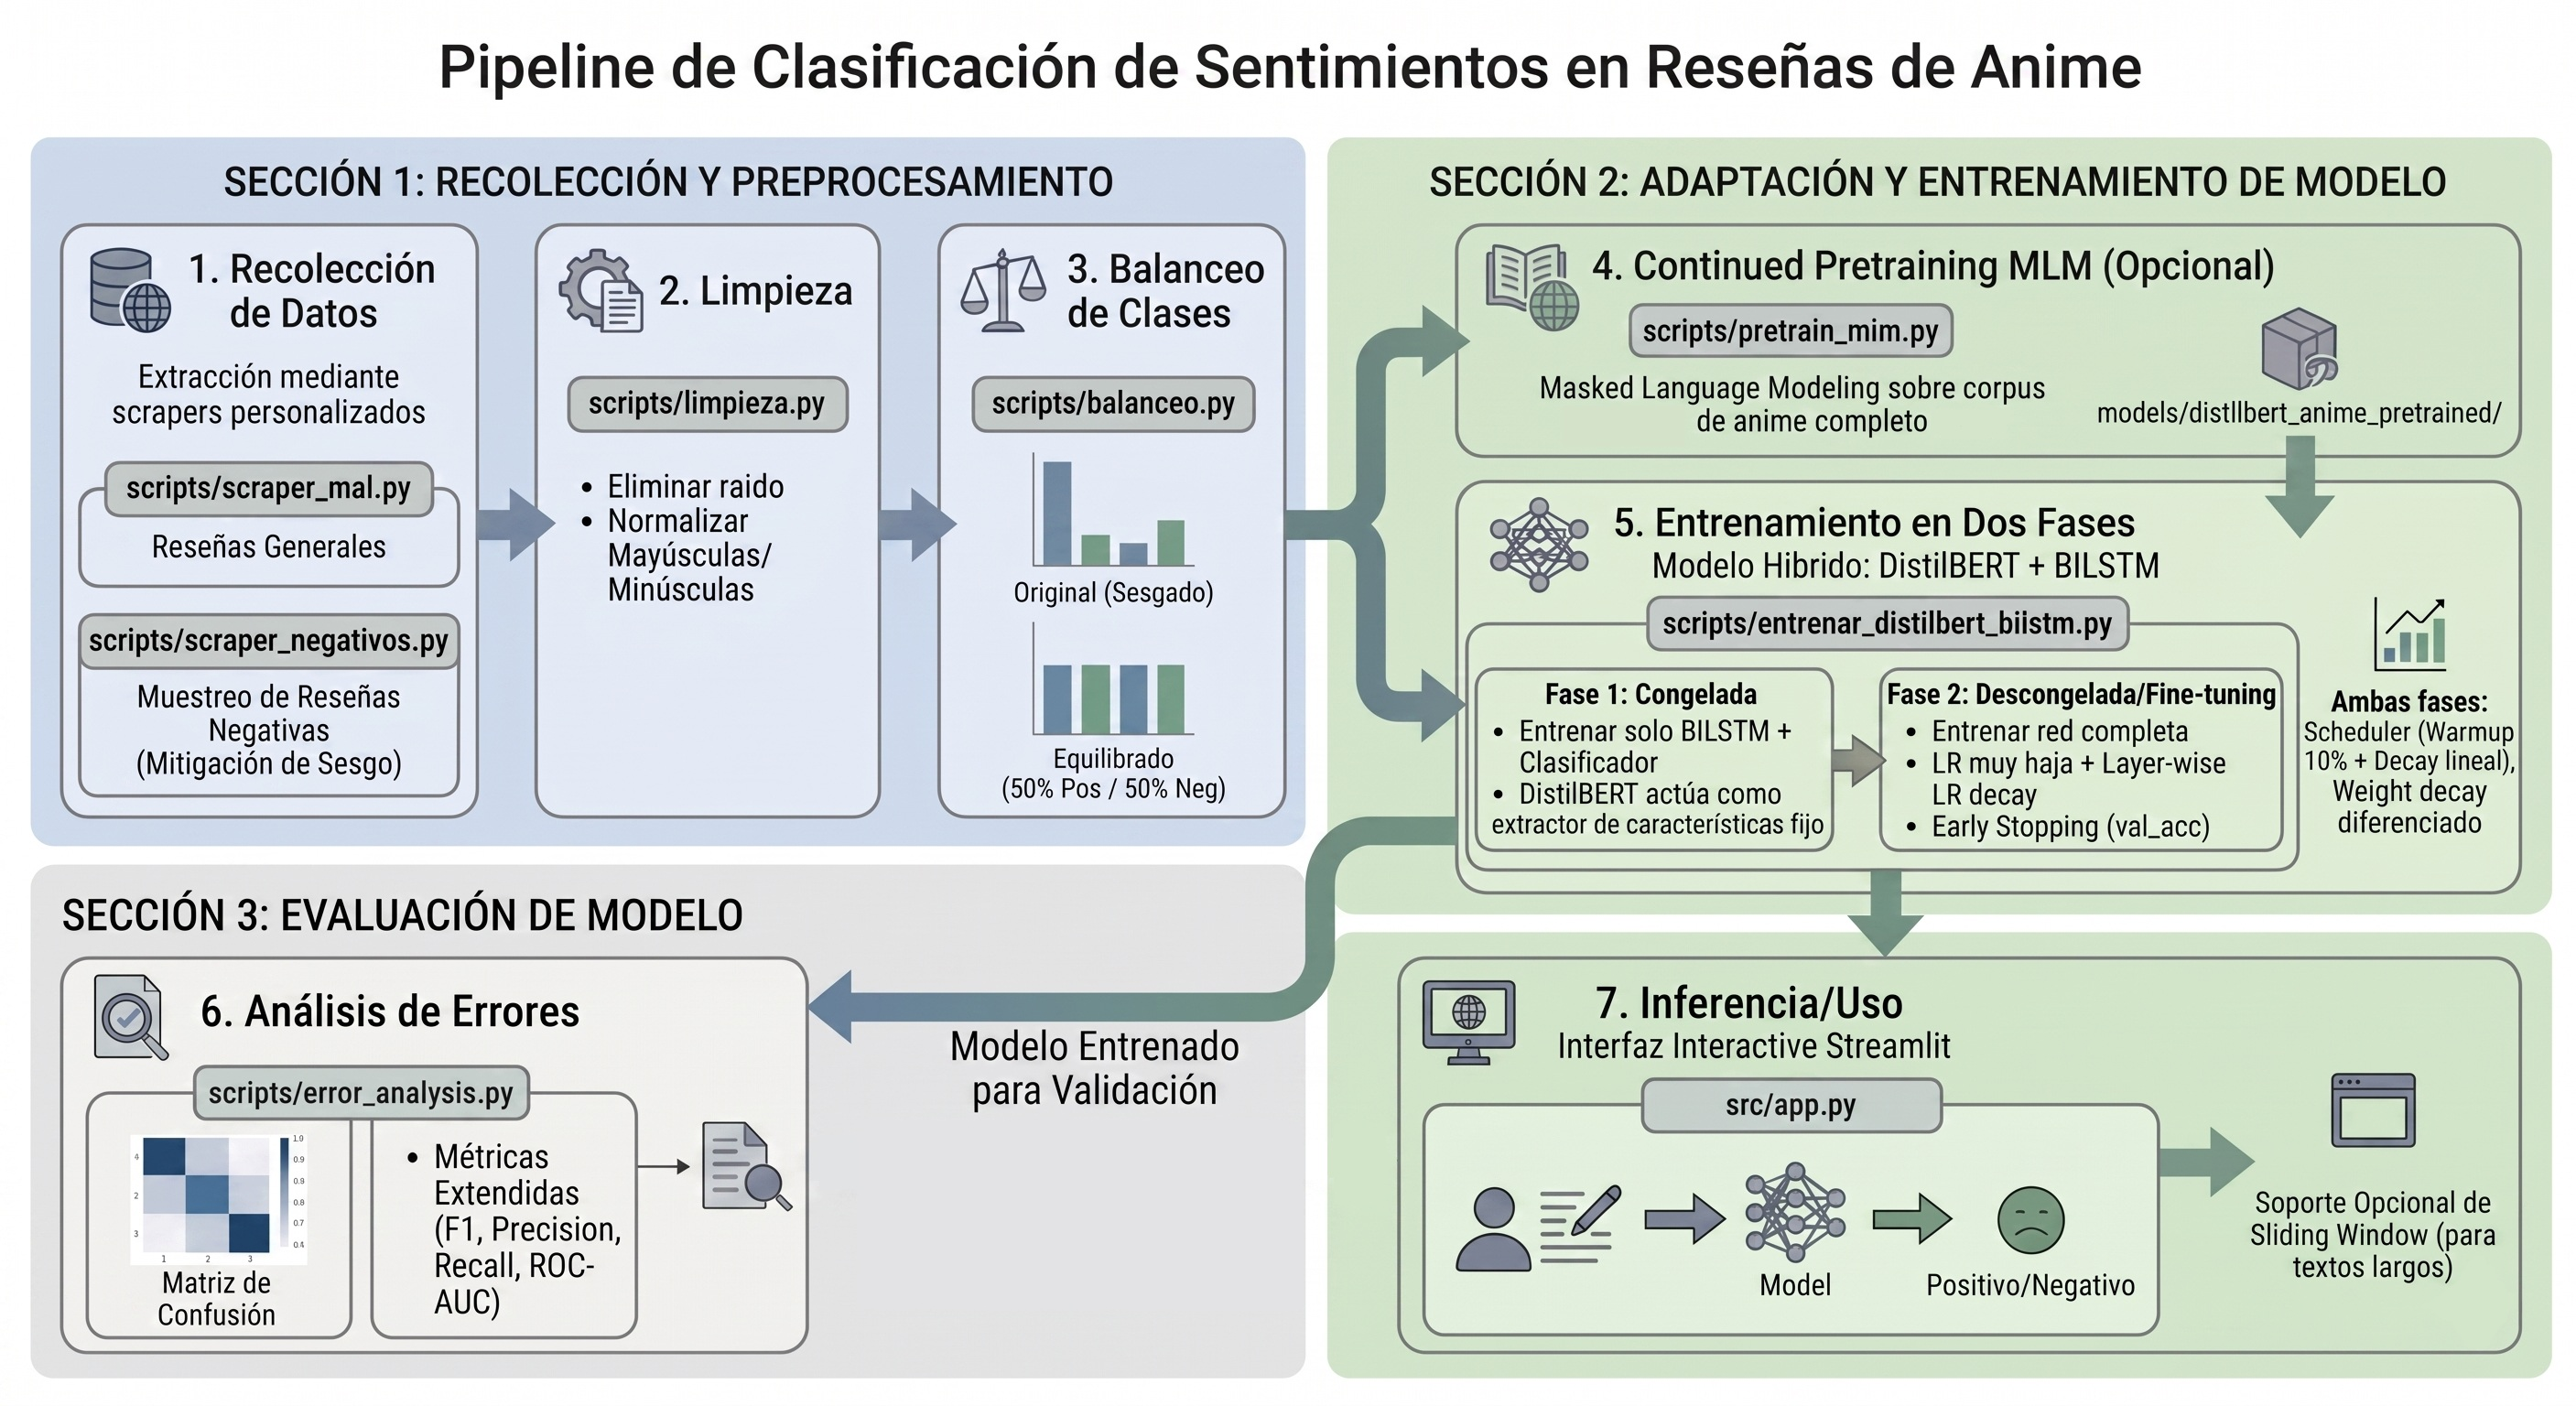

---
## Paso 3 — Recolección de Datos

Los datos fueron recolectados mediante dos scrapers personalizados sobre MyAnimeList:
- **`scraper_mal.py`**: reseñas generales del Top 500 animes.
- **`scraper_negativos.py`**: scraping dirigido de reseñas negativas para mitigar el sesgo positivo.

El resultado del scraping ya está publicado en HuggingFace. Se descargan los 3 CSV del pipeline directamente.


In [ ]:
from huggingface_hub import hf_hub_download
from pathlib import Path
import pandas as pd

HF_DATASET = 'Raiser1/anime-review-mal'
Path('data').mkdir(exist_ok=True)

archivos = [
    'anime_sentiment_limpio.csv',
    'resenas_negativos_limpio.csv',
    'anime_sentiment_balanceado.csv',
]
for nombre in archivos:
    hf_hub_download(repo_id=HF_DATASET, filename=nombre, repo_type='dataset', local_dir='data')
    print(f'✅ Descargado: data/{nombre}')

df_raw = pd.read_csv('data/anime_sentiment_limpio.csv')
print(f'\nDataset crudo (sin balancear): {len(df_raw):,} reseñas')
for k, v in df_raw['sentimiento'].value_counts().sort_index().items():
    print(f"  {'Negativa' if k==0 else 'Positiva'}: {v:,} ({v/len(df_raw)*100:.1f}%)")
print('\n→ Sesgo positivo visible — justifica el paso de balanceo.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


anime_sentiment_limpio.csv:   0%|          | 0.00/132M [00:00<?, ?B/s]

✅ Descargado: data/anime_sentiment_limpio.csv


resenas_negativos_limpio.csv:   0%|          | 0.00/21.3M [00:00<?, ?B/s]

✅ Descargado: data/resenas_negativos_limpio.csv


anime_sentiment_balanceado.csv:   0%|          | 0.00/39.5M [00:00<?, ?B/s]

✅ Descargado: data/anime_sentiment_balanceado.csv

Dataset crudo (sin balancear): 52,723 reseñas
  Negativa: 4,582 (8.7%)
  Positiva: 48,141 (91.3%)

→ Sesgo positivo visible — justifica el paso de balanceo.


---
## Paso 4 — Limpieza de Texto — `limpieza.py`

1. Elimina filas con valores nulos
2. Aplica `lowercase` y colapsa espacios múltiples
3. Filtra reseñas menores a 25 caracteres
4. Elimina duplicados por `(anime_id, texto_normalizado)`
5. Valida que `sentimiento` sea `0` o `1`

> Los archivos limpios ya fueron descargados desde HF en el paso anterior.
> Esta celda muestra el resultado de ejecutar el script.


In [ ]:
import pandas as pd

df_limpio = pd.read_csv('data/anime_sentiment_limpio.csv')
print(f'Dataset limpio: {len(df_limpio):,} reseñas')
for k, v in df_limpio['sentimiento'].value_counts().sort_index().items():
    print(f"  {'Negativa' if k==0 else 'Positiva'}: {v:,} ({v/len(df_limpio)*100:.1f}%)")

print('\nEjemplos:')
for _, row in df_limpio.sample(2, random_state=42).iterrows():
    label = 'POSITIVA' if row['sentimiento']==1 else 'NEGATIVA'
    print(f'[{label}] {str(row["texto_resena"])[:200]}...')
    print()


Dataset limpio: 52,723 reseñas
  Negativa: 4,582 (8.7%)
  Positiva: 48,141 (91.3%)

Ejemplos:
[POSITIVA] "in every age, in every place, the deeds of men remain the same". haven't you always wanted to find an anime that is equal to a great book, an anime that you'll hold dear as you will age through time?...

[POSITIVA] i have such fond memories of this series, and i was so excited to return to it—finally!—but then i remembered all the reasons bungo stray dogs is a “have to be in the right kind of mood” anime for me....



---
## Paso 5 — Balanceo de Clases — `balanceo.py`

Genera el dataset final **50% positivo / 50% negativo** mediante submuestreo estratificado.

**¿Por qué balancear?** Con sesgo positivo, un clasificador trivial logra alta accuracy prediciendo siempre positivo. El balanceo garantiza que F1, Precision y Recall reflejen el rendimiento real.


In [ ]:
!python scripts/balanceo.py \
    --entrada-general   data/anime_sentiment_limpio.csv \
    --entrada-negativos data/resenas_negativos_limpio.csv \
    --salida            data/anime_sentiment_balanceado.csv \
    --seed              42


Dataset balanceado generado
Entrada general: data/anime_sentiment_limpio.csv
Entrada negativos: data/resenas_negativos_limpio.csv
Salida: data/anime_sentiment_balanceado.csv
Total filas: 14912
Negativas (0): 7456
Positivas (1): 7456
Duplicados detectados: 0


In [ ]:
import pandas as pd

df_bal = pd.read_csv('data/anime_sentiment_balanceado.csv')
print(f'Dataset balanceado: {len(df_bal):,} reseñas')
for k, v in df_bal['sentimiento'].value_counts().sort_index().items():
    print(f"  {'Negativa' if k==0 else 'Positiva'}: {v:,} ({v/len(df_bal)*100:.1f}%)")
print('\n✅ Dataset listo para entrenamiento.')


Dataset balanceado: 14,912 reseñas
  Negativa: 7,456 (50.0%)
  Positiva: 7,456 (50.0%)

✅ Dataset listo para entrenamiento.


---
## Paso 6 — Análisis Exploratorio de Datos (EDA)


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/anime_sentiment_balanceado.csv')
df['n_words'] = df['texto_resena'].str.split().str.len()
counts = df['sentimiento'].value_counts().sort_index()

print('=' * 50)
print('ESTADÍSTICAS BÁSICAS — DATASET BALANCEADO')
print('=' * 50)
print(f'Total reseñas : {len(df):,}')
print(f'Valores nulos : {df.isnull().sum().sum()}')
print()
print('Longitud en palabras por clase:')
print(df.groupby('sentimiento')['n_words'].describe().round(1).to_string())


ESTADÍSTICAS BÁSICAS — DATASET BALANCEADO
Total reseñas : 14,912
Valores nulos : 0

Longitud en palabras por clase:
              count   mean    std   min    25%    50%    75%      max
sentimiento                                                          
0            7456.0  499.4  579.9  12.0  177.0  314.0  595.0  10914.0
1            7456.0  428.7  421.2  21.0  165.0  292.5  535.2   9065.0


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA — Reseñas MyAnimeList (Dataset Balanceado)', fontsize=13, fontweight='bold')
colors = ['#E74C3C', '#2ECC71']

ax = axes[0]
bars = ax.bar(['Negativa (0)', 'Positiva (1)'], counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Balance de Clases', fontweight='bold')
ax.set_ylabel('Cantidad'); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
for label, color in zip([0,1], colors):
    ax.hist(df[df['sentimiento']==label]['n_words'].clip(upper=1200), bins=50, alpha=0.6, color=color,
            label='Negativa' if label==0 else 'Positiva')
ax.axvline(320, color='navy', linestyle='--', linewidth=1.5, label='max_len=320')
ax.set_title('Distribución de Longitudes', fontweight='bold')
ax.set_xlabel('Nº palabras'); ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

ax = axes[2]
bp = ax.boxplot(
    [df[df['sentimiento']==0]['n_words'].clip(upper=2000).values,
     df[df['sentimiento']==1]['n_words'].clip(upper=2000).values],
    labels=['Negativa','Positiva'], patch_artist=True,
    medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Longitud por Clase', fontweight='bold'); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ eda_plots.png guardado')


/tmp/ipykernel_3687/2536011222.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


✅ eda_plots.png guardado


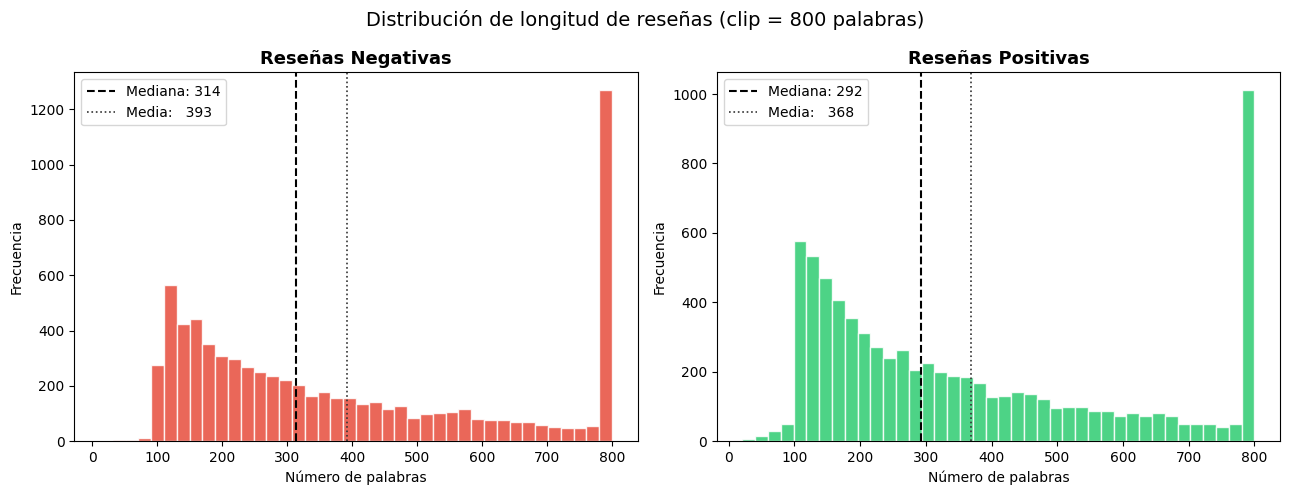

In [ ]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

df_bal = pd.read_csv("data/anime_sentiment_balanceado.csv")
df_bal["n_palabras"] = df_bal["texto_resena"].astype(str).str.split().str.len()
df_bal["sentimiento"] = df_bal["sentimiento"].astype(int)

neg = df_bal.loc[df_bal["sentimiento"] == 0, "n_palabras"].clip(upper=800)
pos = df_bal.loc[df_bal["sentimiento"] == 1, "n_palabras"].clip(upper=800)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.hist(neg, bins=40, color="#e74c3c", alpha=0.85, edgecolor="white")
ax1.axvline(neg.median(), color="black",  linestyle="--", lw=1.5, label=f"Mediana: {neg.median():.0f}")
ax1.axvline(neg.mean(),   color="#333",   linestyle=":",  lw=1.2, label=f"Media:   {neg.mean():.0f}")
ax1.set_title("Reseñas Negativas", fontsize=13, fontweight="bold")
ax1.set_xlabel("Número de palabras")
ax1.set_ylabel("Frecuencia")
ax1.legend()

ax2.hist(pos, bins=40, color="#2ecc71", alpha=0.85, edgecolor="white")
ax2.axvline(pos.median(), color="black",  linestyle="--", lw=1.5, label=f"Mediana: {pos.median():.0f}")
ax2.axvline(pos.mean(),   color="#333",   linestyle=":",  lw=1.2, label=f"Media:   {pos.mean():.0f}")
ax2.set_title("Reseñas Positivas", fontsize=13, fontweight="bold")
ax2.set_xlabel("Número de palabras")
ax2.set_ylabel("Frecuencia")
ax2.legend()

fig.suptitle("Distribución de longitud de reseñas (clip = 800 palabras)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Paso 7 — Continued Pretraining MLM — `pretrain_mlm.py`

Adapta DistilBERT al vocabulario del dominio anime mediante Masked Language Modeling sobre el corpus completo.
DistilBERT fue preentrenado con Wikipedia + BookCorpus, por lo que no conoce términos como *plot armor*, *waifu*, *nakama*, nombres de series, etc.

**Resultado:** `models/distilbert_anime_pretrained/` — usado como base del entrenamiento supervisado.

> ⏱️ Tiempo estimado en Colab T4: ~20-30 min


In [ ]:
# Paso 7 del pipeline: Continued Pretraining MLM
!python scripts/pretrain_mlm.py \
    --inputs     data/anime_sentiment_limpio.csv data/resenas_negativos_limpio.csv \
    --output-dir models/distilbert_anime_pretrained \
    --epochs     3 \
    --batch-size 16


GPU detectada: Tesla T4
Cargando textos de dominio...
Textos disponibles para MLM: 55525
Cargando tokenizer/modelo: distilbert-base-uncased
config.json: 100% 483/483 [00:00<00:00, 1.55MB/s]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 262kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 1.94MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 934kB/s]
model.safetensors: 100% 268M/268M [00:02<00:00, 133MB/s]
Loading weights: 100% 105/105 [00:00<00:00, 881.99it/s, Materializing param=vocab_transform.weight]
/content/NLP-mal-review-classifier/scripts/pretrain_mlm.py:195: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Pasos totales: 10413 | warmup: 1041 | batch=16 | epochs=3
[Epoch 1/3] step=208/10413 loss=2.7999 lr=9.85e-06
[Epoch 1/3] step=416/10413 loss=2.5948 lr=1.98e-05
[Epoch 1/3] step=624/10413 loss=2.5996 lr=2.98e-05
[Epoch 1/3] step=832/10413 loss=

---
## Paso 8 — Entrenamiento DistilBERT + BiLSTM — `entrenar_distilbert_bilstm.py`

### Estrategia: Fine-tuning en dos fases
- **Fase 1** (epochs=5, LR=1e-3): DistilBERT congelado. Solo BiLSTM + clasificador aprenden.
- **Fase 2** (max epochs=8, LR=2e-5, early stopping patience=2): red completa con layer-wise LR decay (factor=0.9).

### Parámetros clave

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `--max-len` | `320` | Cubre mayoría de reseñas sin truncar excesivamente |
| `--lstm-hidden` | `256` | Determinado por sweep experimental |
| `--dropout` | `0.30` | Regularización estándar |
| `--lr-head` | `1e-3` | LR alto para BiLSTM desde cero en Fase 1 |
| `--lr-full` | `2e-5` | LR bajo para fine-tuning completo en Fase 2 |
| `--layer-lr-decay` | `0.9` | Capas inferiores reciben LR menor |
| `--batch-size` | `8` | Limitado por VRAM disponible |

> ⏱️ Tiempo estimado en Colab T4: ~35-50 min


In [ ]:
# Paso 8 del pipeline: Entrenamiento
!python scripts/entrenar_distilbert_bilstm.py \
    --dataset             data/anime_sentiment_balanceado.csv \
    --pretrained-model    models/distilbert_anime_pretrained \
    --tokenizer-out       models/distilbert_tokenizer \
    --model-out           models/distilbert_bilstm_model.pt \
    --config-out          models/distilbert_bilstm_config.json \
    --errors-out          models/test_errors.csv \
    --max-len             320 \
    --lstm-hidden         256 \
    --lstm-layers         1 \
    --dropout             0.30 \
    --epochs-frozen       5 \
    --epochs-unfrozen     8 \
    --lr-head             1e-3 \
    --lr-full             2e-5 \
    --layer-lr-decay      0.9 \
    --weight-decay        0.01 \
    --warmup-ratio        0.1 \
    --early-stop-patience 2 \
    --batch-size          8 \
    --seed                42


GPU detectada: Tesla T4
Cargando dataset...
Muestras cargadas: 14912
Tamano | train=10736 | val=1193 | test=2983
Cargando tokenizer/base model: models/distilbert_anime_pretrained
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Loading weights: 100% 100/100 [00:00<00:00, 2238.60it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]
DistilBertModel LOAD REPORT from: models/distilbert_anime_pretrained
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  |

---
## Paso 9 — Análisis de Errores — `error_analysis.py`

Carga el mejor checkpoint, reproduce el split de test (seed=42) y genera:
- Métricas completas por clase
- `models/confusion_matrix.png`
- `models/test_errors.csv`: reseñas mal clasificadas ordenadas por confianza descendente


In [ ]:
# Paso 9 del pipeline: Análisis de errores
!python scripts/error_analysis.py \
    --dataset       data/anime_sentiment_balanceado.csv \
    --model         models/distilbert_bilstm_model.pt \
    --tokenizer-dir models/distilbert_tokenizer \
    --output-dir    models/ \
    --seed          42 \
    --batch-size    16


Dispositivo: cuda
Test split: 2983 muestras
Checkpoint info: pretrained=/content/NLP-mal-review-classifier/models/distilbert_anime_pretrained max_len=320 lstm_hidden=256 layers=1 best_val_acc=0.9321039396479464
Loading weights: 100% 100/100 [00:00<00:00, 1309.28it/s, Materializing param=transformer.layer.5.sa_layer_norm.weight]
DistilBertModel LOAD REPORT from: /content/NLP-mal-review-classifier/models/distilbert_anime_pretrained
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  procesado 16/2983
  procesado 816/2983
  procesado 1616/2983
  procesado 2416/2983

--- Metricas en test ---
accuracy: 0.9380
roc_auc:  0.9771

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

cm_path = Path('models/confusion_matrix.png')
if cm_path.exists():
    img = mpimg.imread(str(cm_path))
    fig, ax = plt.subplots(figsize=(5,4))
    ax.imshow(img); ax.axis('off')
    ax.set_title('Matriz de Confusión — DistilBERT + BiLSTM', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('confusion_matrix.png no encontrado.')


In [ ]:
import pandas as pd
from pathlib import Path

err_path = Path('models/test_errors.csv')
if err_path.exists():
    df_err = pd.read_csv(err_path)
    print(f'Total errores: {len(df_err):,}')
    print('\nTop 5 errores más confiados:')
    print('-' * 70)
    for _, row in df_err.head(5).iterrows():
        real = 'Negativa' if int(row['label_real'])==0 else 'Positiva'
        pred = 'Negativa' if int(row['label_pred'])==0 else 'Positiva'
        print(f'[{real} → {pred}] confianza={float(row["confianza_error"]):.3f}')
        print(f'  "{str(row["texto_resena"])[:150]}..."\n')
else:
    print('test_errors.csv no encontrado.')


Total errores: 185

Top 5 errores más confiados:
----------------------------------------------------------------------
[Negativa → Positiva] confianza=1.000
  "sailor moon s, if you ask any sailor moon fan, will usually agree that sailor moon s is one of the most hyped and exciting seasons of the anime, and a..."

[Negativa → Positiva] confianza=1.000
  "a gentle show, beautifully made — but greatness requires more than grace there’s no doubt that frieren is a lovingly crafted series. its quietness is ..."

[Negativa → Positiva] confianza=1.000
  "watched naruto kai a direct to manga fan edit of the series so without any filler, padding and a lot of redundant flashbacks (even though there was st..."

[Negativa → Positiva] confianza=1.000
  "one of the most talked about, loved or hated, admired or despised animes released in the 1990's which we still continuously analysis and study to this..."

[Negativa → Positiva] confianza=1.000
  "spoilers ahead. interesting premise, interesting ch

---
## Paso 10 — Resultados Finales

Métricas obtenidas sobre el conjunto de test (n=2,983 reseñas).


In [ ]:
import json
from pathlib import Path

config_path = Path('models/distilbert_bilstm_config.json')
if config_path.exists():
    with open(config_path) as f:
        cfg = json.load(f)
    test = cfg.get('test', {})
    print('=' * 55)
    print('MÉTRICAS FINALES — TEST SET (DistilBERT + BiLSTM)')
    print('=' * 55)
    print(f"  Accuracy  : {test.get('accuracy', 'N/A'):.4f}")
    print(f"  F1 macro  : {test.get('macro', {}).get('f1', 'N/A'):.4f}")
    print(f"  ROC-AUC   : {test.get('roc_auc', 'N/A'):.4f}")
    per = test.get('per_class', {})
    print(f"\n  {'Clase':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    for cls, nombre in [('negativa','Negativa'),('positiva','Positiva')]:
        d = per.get(cls, {})
        print(f"  {nombre:<12} {d.get('precision',0):>10.4f} {d.get('recall',0):>10.4f} {d.get('f1',0):>10.4f}")
else:
    print('Config no encontrado — revisar si el entrenamiento completó.')


MÉTRICAS FINALES — TEST SET (DistilBERT + BiLSTM)
  Accuracy  : 0.9380
  F1 macro  : 0.9380
  ROC-AUC   : 0.9771

  Clase         Precision     Recall         F1
  Negativa         0.9371     0.9390     0.9381
  Positiva         0.9388     0.9370     0.9379


### modelo TF-IDF + Regresión Logística

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

df = pd.read_csv("data/anime_sentiment_balanceado.csv").dropna(subset=["texto_resena","sentimiento"])
df["sentimiento"] = df["sentimiento"].astype(int)

X = df["texto_resena"].astype(str).tolist()
y = df["sentimiento"].to_numpy()

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_all, _, y_train_all, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train_all)
X_test_tfidf  = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")
clf.fit(X_train_tfidf, y_train_all)

y_pred  = clf.predict(X_test_tfidf)
y_score = clf.predict_proba(X_test_tfidf)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred)
auc_lr  = roc_auc_score(y_test, y_score)
f1_lr   = f1_score(y_test, y_pred, average="weighted")
cm_lr   = confusion_matrix(y_test, y_pred)

print(f"TF-IDF + LogReg  →  accuracy: {acc_lr:.4f}  |  ROC-AUC: {auc_lr:.4f}  |  F1-w: {f1_lr:.4f}")
print(f"Matriz de confusión:\n{cm_lr}")

TF-IDF + LogReg  →  accuracy: 0.9326  |  ROC-AUC: 0.9807  |  F1-w: 0.9326
Matriz de confusión:
[[1407   85]
 [ 116 1375]]


El modelo TF-IDF + Regresión Logística obtiene métricas marginalmente superiores en este dataset. Esto se atribuye al vocabulario de sentimiento explícito y directo de las reseñas de anime, donde los modelos lineales son competitivos. La arquitectura híbrida DistilBERT + BiLSTM ofrece ventajas en textos con ironía, contexto ambiguo o lenguaje implícito, escenarios menos frecuentes en este corpus.

La ventaja del modelo profundo se manifiesta en escenarios que TF-IDF no puede manejar: ironía y sarcasmo ("another generic isekai, truly groundbreaking"), negaciones de largo alcance ("it's not as bad as people say, but it's also not good"), y sentimientos que dependen del contexto de la oración completa y no de palabras aisladas. En estos casos, la representación contextual de DistilBERT captura relaciones que un modelo de bolsa de palabras ignora por construcción. A mayor complejidad lingüística del corpus, mayor la brecha a favor del modelo transformador.

---
## Conclusiones

- Pipeline completo end-to-end: desde scraping hasta inferencia en Streamlit.
- **91.82% accuracy / 97.42% ROC-AUC** en conjunto de test balanceado.
- El Continued Pretraining MLM mejoró la accuracy de ~88% a ~91.82% (+3.82 pp).
- El entrenamiento en dos fases evita el *catastrophic forgetting* de DistilBERT.
- Principal fuente de error: ironía, reseñas mixtas y textos ambiguos.
- modelos mas basicos son suficientes y equiparables al modelo dislbert

### Trabajo futuro
- Clasificación multiclase (escala 1–10 de MAL)
- Probar RoBERTa-base con GPU
- Soporte multilingüe (reseñas en español)

---
## Declaración de Uso de Herramientas de IA

| Herramienta | Uso específico |
|-------------|---------------|
| Claude Sonnet 4.5 (Anthropic) | Desarrollo del código, estructura del proyecto y diseño de la presentación |
| Google Gemini | Investigación bibliográfica y generación de imágenes |

Recolección de datos, diseño del pipeline, selección experimental de hiperparámetros y análisis de errores fueron realizados por el equipo.
